In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import time
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Memory: 3.7 GB


## Section 2: Define ResNet-56 Architecture

ResNet-56 consists of 56 convolutional layers with approximately 850,000 parameters. The architecture follows the standard ResNet design with three residual block groups.

In [2]:
class BasicBlock(nn.Module):
    """Basic residual block for ResNet-56"""
    
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        
        # First convolutional layer
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, 
                              stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        # Second convolutional layer
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, 
                              stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # Shortcut connection
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, 
                         stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class ResNet56(nn.Module):
    """
    ResNet-56 architecture for CIFAR-10/100
    
    Architecture:
    - Initial conv: 3x3, 16 filters
    - Block 1: 9 layers, 16 filters (32x32)
    - Block 2: 9 layers, 32 filters (16x16, stride 2)
    - Block 3: 9 layers, 64 filters (8x8, stride 2)
    - Classifier: Global Average Pooling + FC
    
    Total: 56 convolutional layers, ~850K parameters
    """
    
    def __init__(self, num_classes=10):
        super(ResNet56, self).__init__()
        
        # Initial convolution layer
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        
        # Residual blocks
        # Block 1: 9 layers, 16 filters (no downsampling)
        self.layer1 = self._make_layer(16, 16, 9, stride=1)
        
        # Block 2: 9 layers, 32 filters (downsample 32x32 → 16x16)
        self.layer2 = self._make_layer(16, 32, 9, stride=2)
        
        # Block 3: 9 layers, 64 filters (downsample 16x16 → 8x8)
        self.layer3 = self._make_layer(32, 64, 9, stride=2)
        
        # Classification head
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)
        
        # Initialize weights
        self._initialize_weights()
    
    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = []
        
        # First block may have stride > 1 for downsampling
        layers.append(BasicBlock(in_channels, out_channels, stride))
        
        # Remaining blocks have stride = 1
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_channels, out_channels, stride=1))
        
        return nn.Sequential(*layers)
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        # Initial convolution
        out = F.relu(self.bn1(self.conv1(x)))
        
        # Residual blocks
        out = self.layer1(out)  # 32x32x16
        out = self.layer2(out)  # 16x16x32
        out = self.layer3(out)  # 8x8x64
        
        # Global average pooling and classification
        out = self.avgpool(out)  # 1x1x64
        out = out.view(out.size(0), -1)  # Flatten
        out = self.fc(out)  # num_classes
        
        return out


def count_parameters(model):
    """Count total and trainable parameters"""
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params


# Test ResNet-56 architecture
print("=== ResNet-56 Architecture Test ===")
model_test = ResNet56(num_classes=10)
total_params, trainable_params = count_parameters(model_test)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: {total_params * 4 / 1024**2:.2f} MB (float32)")

# Test forward pass
test_input = torch.randn(1, 3, 32, 32)
test_output = model_test(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {test_output.shape}")

# Display model architecture summary
print("\n=== Model Architecture Summary ===")
print(model_test)

=== ResNet-56 Architecture Test ===
Total parameters: 855,770
Trainable parameters: 855,770
Model size: 3.26 MB (float32)
Input shape: torch.Size([1, 3, 32, 32])
Output shape: torch.Size([1, 10])

=== Model Architecture Summary ===
ResNet56(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): 

## Section 3: Implement Magnitude-based Attention Pruning (MAP)

The MAP method uses magnitude-based attention to dynamically prune weights during training. Key features:
- **Mask updates every 16 iterations** (~24 updates per epoch)
- **Gradual sparsity increase** from 0% to target sparsity by epoch 225
- **Straight-Through Estimator (STE)** for gradient flow through pruned weights

In [3]:
class MAPPruner:
    """
    Magnitude-based Attention Pruning (MAP) implementation
    
    Key Features:
    - Mask updates every 16 iterations
    - Gradual sparsity increase during exploration phase
    - Magnitude attention values for weight importance
    - Straight-Through Estimator for gradient flow
    """
    
    def __init__(self, model, target_sparsity=0.9, mask_update_freq=16, 
                 total_epochs=300, exploration_end=225, exploitation_start=250):
        self.model = model
        self.target_sparsity = target_sparsity
        self.mask_update_freq = mask_update_freq
        self.total_epochs = total_epochs
        self.exploration_end = exploration_end
        self.exploitation_start = exploitation_start
        
        # Initialize masks and attention values
        self.masks = {}
        self.attention_values = {}
        self.current_sparsity = 0.0
        self.iteration_count = 0
        self.mask_frozen = False
        
        # Initialize masks for all conv and linear layers
        self._initialize_masks()
        
        # Statistics tracking
        self.sparsity_history = []
        self.mask_update_history = []
    
    def _initialize_masks(self):
        """Initialize pruning masks for all prunable layers"""
        for name, module in self.model.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)):
                # Initialize mask as all ones (no pruning initially)
                self.masks[name] = torch.ones_like(module.weight.data)
                # Initialize attention values based on weight magnitudes
                self.attention_values[name] = torch.abs(module.weight.data.clone())
    
    def _calculate_global_threshold(self, sparsity_ratio):
        """Calculate global threshold for given sparsity ratio"""
        all_weights = []
        
        for name, module in self.model.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)) and name in self.masks:
                weights_flat = torch.abs(module.weight.data).view(-1)
                all_weights.append(weights_flat)
        
        if not all_weights:
            return 0.0
        
        all_weights = torch.cat(all_weights)
        k = int(len(all_weights) * sparsity_ratio)
        
        if k >= len(all_weights):
            return float('inf')
        if k <= 0:
            return 0.0
        
        threshold, _ = torch.kthvalue(all_weights, k)
        return threshold.item()
    
    def _update_masks(self, current_epoch):
        """Update pruning masks based on current sparsity schedule"""
        if self.mask_frozen:
            return
        
        # Calculate current target sparsity (gradual increase)
        if current_epoch < self.exploration_end:
            # Linear increase during exploration
            progress = current_epoch / self.exploration_end
            current_target_sparsity = self.target_sparsity * progress
        else:
            current_target_sparsity = self.target_sparsity
        
        # Calculate threshold for current sparsity
        threshold = self._calculate_global_threshold(current_target_sparsity)
        
        # Update masks and attention values
        total_weights = 0
        pruned_weights = 0
        
        for name, module in self.model.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)) and name in self.masks:
                # Update attention values based on current weight magnitudes
                self.attention_values[name] = torch.abs(module.weight.data.clone())
                
                # Create new mask based on threshold
                self.masks[name] = (self.attention_values[name] > threshold).float()
                
                # Count statistics
                total_weights += module.weight.numel()
                pruned_weights += (self.masks[name] == 0).sum().item()
        
        # Update current sparsity
        self.current_sparsity = pruned_weights / total_weights if total_weights > 0 else 0.0
        self.sparsity_history.append(self.current_sparsity)
        
        # Track mask updates
        self.mask_update_history.append({
            'epoch': current_epoch,
            'iteration': self.iteration_count,
            'sparsity': self.current_sparsity,
            'threshold': threshold
        })
    
    def apply_masks(self):
        """Apply current masks to model weights with STE"""
        for name, module in self.model.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)) and name in self.masks:
                # Apply mask using straight-through estimator
                # Forward: masked weights, Backward: full gradients
                module.weight.data = module.weight.data * self.masks[name]
    
    def step(self, current_epoch):
        """Perform one pruning step"""
        self.iteration_count += 1
        
        # Check if masks should be frozen (exploitation phase)
        if current_epoch >= self.exploitation_start:
            self.mask_frozen = True
        
        # Update masks if needed
        if (self.iteration_count % self.mask_update_freq == 0 and 
            not self.mask_frozen):
            self._update_masks(current_epoch)
        
        # Always apply current masks
        self.apply_masks()
    
    def get_statistics(self):
        """Get current pruning statistics"""
        total_params = 0
        pruned_params = 0
        
        for name, module in self.model.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)) and name in self.masks:
                total_params += module.weight.numel()
                pruned_params += (self.masks[name] == 0).sum().item()
        
        current_sparsity = pruned_params / total_params if total_params > 0 else 0.0
        
        return {
            'total_parameters': total_params,
            'pruned_parameters': pruned_params,
            'remaining_parameters': total_params - pruned_params,
            'sparsity_ratio': current_sparsity,
            'mask_frozen': self.mask_frozen,
            'total_mask_updates': len(self.mask_update_history)
        }


class StraightThroughEstimator(torch.autograd.Function):
    """
    Straight-Through Estimator for gradient flow through pruned weights
    Forward: Apply mask, Backward: Pass gradient through unchanged
    """
    
    @staticmethod
    def forward(ctx, input, mask):
        return input * mask
    
    @staticmethod 
    def backward(ctx, grad_output):
        # Pass gradients through unchanged (ignoring mask)
        return grad_output, None


def apply_ste_masks(model, masks):
    """Apply masks using Straight-Through Estimator"""
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)) and name in masks:
            module.weight.data = StraightThroughEstimator.apply(
                module.weight.data, masks[name]
            )


# Test MAP implementation
print("=== Testing MAP Pruner ===")
test_model = ResNet56(num_classes=10)
map_pruner = MAPPruner(test_model, target_sparsity=0.9)

print("Initial statistics:")
stats = map_pruner.get_statistics()
for key, value in stats.items():
    print(f"  {key}: {value}")

# Simulate a few mask updates
print("\nSimulating mask updates...")
for epoch in [0, 50, 100, 150, 200, 225, 250, 275]:
    for _ in range(24):  # ~24 updates per epoch
        map_pruner.step(epoch)
    
    stats = map_pruner.get_statistics()
    print(f"Epoch {epoch:3d}: Sparsity = {stats['sparsity_ratio']:.3f}, "
          f"Frozen = {stats['mask_frozen']}, Updates = {stats['total_mask_updates']}")

print(f"\nFinal sparsity: {map_pruner.current_sparsity:.3f}")
print(f"Total mask updates: {len(map_pruner.mask_update_history)}")

=== Testing MAP Pruner ===
Initial statistics:
  total_parameters: 851504
  pruned_parameters: 0
  remaining_parameters: 851504
  sparsity_ratio: 0.0
  mask_frozen: False
  total_mask_updates: 0

Simulating mask updates...
Epoch   0: Sparsity = 0.000, Frozen = False, Updates = 1
Epoch  50: Sparsity = 0.200, Frozen = False, Updates = 3
Epoch 100: Sparsity = 0.400, Frozen = False, Updates = 4
Epoch 150: Sparsity = 0.600, Frozen = False, Updates = 6
Epoch 200: Sparsity = 0.800, Frozen = False, Updates = 7
Epoch 225: Sparsity = 0.900, Frozen = False, Updates = 9
Epoch 250: Sparsity = 0.900, Frozen = True, Updates = 9
Epoch 275: Sparsity = 0.900, Frozen = True, Updates = 9

Final sparsity: 0.900
Total mask updates: 9
Epoch 200: Sparsity = 0.800, Frozen = False, Updates = 7
Epoch 225: Sparsity = 0.900, Frozen = False, Updates = 9
Epoch 250: Sparsity = 0.900, Frozen = True, Updates = 9
Epoch 275: Sparsity = 0.900, Frozen = True, Updates = 9

Final sparsity: 0.900
Total mask updates: 9


## Section 4: Setup CIFAR Dataset Loading

Load and preprocess CIFAR-10/100 datasets with appropriate data augmentation and normalization for ResNet training.

=== Loading CIFAR10 Dataset ===
Dataset: CIFAR10
Number of classes: 10
Training samples: 50,000
Test samples: 10,000
Batch size: 128
Training batches per epoch: 391
Test batches: 79
Dataset: CIFAR10
Number of classes: 10
Training samples: 50,000
Test samples: 10,000
Batch size: 128
Training batches per epoch: 391
Test batches: 79


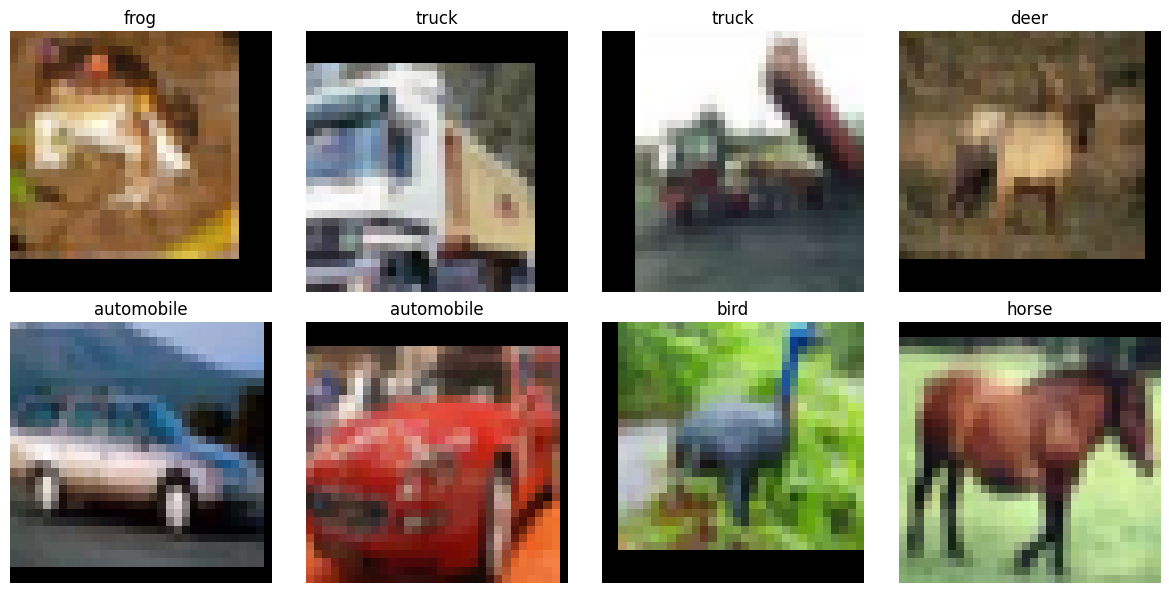

In [4]:
def get_cifar_datasets(dataset_name='cifar10', data_dir='./data'):
    """
    Load CIFAR-10 or CIFAR-100 datasets with appropriate preprocessing
    
    Args:
        dataset_name: 'cifar10' or 'cifar100'
        data_dir: Directory to store/load data
    
    Returns:
        train_dataset, test_dataset, num_classes
    """
    
    # CIFAR mean and std for normalization
    if dataset_name.lower() == 'cifar10':
        mean = [0.4914, 0.4822, 0.4465]
        std = [0.2023, 0.1994, 0.2010]
        num_classes = 10
        dataset_class = torchvision.datasets.CIFAR10
    elif dataset_name.lower() == 'cifar100':
        mean = [0.5071, 0.4867, 0.4408]
        std = [0.2675, 0.2565, 0.2761]
        num_classes = 100
        dataset_class = torchvision.datasets.CIFAR100
    else:
        raise ValueError("dataset_name must be 'cifar10' or 'cifar100'")
    
    # Training data augmentation (standard for CIFAR)
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])
    
    # Test data preprocessing (no augmentation)
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])
    
    # Load datasets
    train_dataset = dataset_class(
        root=data_dir, 
        train=True, 
        download=True, 
        transform=train_transform
    )
    
    test_dataset = dataset_class(
        root=data_dir, 
        train=False, 
        download=True, 
        transform=test_transform
    )
    
    return train_dataset, test_dataset, num_classes


def create_data_loaders(train_dataset, test_dataset, batch_size=128, num_workers=4):
    """Create data loaders for training and testing"""
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    return train_loader, test_loader


# Dataset configuration
DATASET_NAME = 'cifar10'  # Change to 'cifar100' for CIFAR-100
BATCH_SIZE = 128
DATA_DIR = './data'

print(f"=== Loading {DATASET_NAME.upper()} Dataset ===")

# Load datasets
train_dataset, test_dataset, num_classes = get_cifar_datasets(
    dataset_name=DATASET_NAME, 
    data_dir=DATA_DIR
)

# Create data loaders
train_loader, test_loader = create_data_loaders(
    train_dataset, 
    test_dataset, 
    batch_size=BATCH_SIZE
)

print(f"Dataset: {DATASET_NAME.upper()}")
print(f"Number of classes: {num_classes}")
print(f"Training samples: {len(train_dataset):,}")
print(f"Test samples: {len(test_dataset):,}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Training batches per epoch: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

# Display sample images
def show_sample_images(dataset, dataset_name, num_samples=8):
    """Display sample images from the dataset"""
    
    # CIFAR class names
    if dataset_name.lower() == 'cifar10':
        class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                      'dog', 'frog', 'horse', 'ship', 'truck']
    else:
        # For CIFAR-100, we'll just use class indices
        class_names = [f'Class {i}' for i in range(100)]
    
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.ravel()
    
    for i in range(num_samples):
        image, label = dataset[i]
        
        # Denormalize image for display
        if dataset_name.lower() == 'cifar10':
            mean = torch.tensor([0.4914, 0.4822, 0.4465])
            std = torch.tensor([0.2023, 0.1994, 0.2010])
        else:
            mean = torch.tensor([0.5071, 0.4867, 0.4408])
            std = torch.tensor([0.2675, 0.2565, 0.2761])
        
        image = image * std.view(-1, 1, 1) + mean.view(-1, 1, 1)
        image = torch.clamp(image, 0, 1)
        
        # Convert to numpy and transpose for matplotlib
        image_np = image.permute(1, 2, 0).numpy()
        
        axes[i].imshow(image_np)
        axes[i].set_title(f'{class_names[label]}')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Show sample images
show_sample_images(train_dataset, DATASET_NAME)

## Section 5: Configure Training Hyperparameters

Set up all training hyperparameters following the MAP paper specifications:
- **SGD with Nesterov momentum (0.9)**
- **Weight decay (L2): 1e-4**
- **Learning rate schedule**: 0.2 → 0.02 → 0.002
- **Batch size**: 128 samples

In [5]:
# Training Configuration - SMOKE TEST (10 epochs)
class TrainingConfig:
    """Complete training configuration for ResNet-56 MAP - SMOKE TEST VERSION"""
    
    def __init__(self):
        # Model and dataset
        self.num_classes = num_classes
        self.dataset_name = DATASET_NAME
        
        # SMOKE TEST: Reduced training schedule
        self.total_epochs = 10          # Reduced from 300 to 10
        self.batch_size = 128
        
        # Learning rate schedule (adjusted for smoke test)
        self.initial_lr = 0.2          # Start with normal LR
        self.mid_lr = 0.02             # Will trigger at epoch 5
        self.final_lr = 0.002          # Will trigger at epoch 8
        self.lr_schedule = [5, 8]      # Reduced from [150, 225]
        
        # Optimizer parameters
        self.momentum = 0.9            # Nesterov momentum
        self.weight_decay = 1e-4       # L2 regularization
        self.nesterov = True
        
        # MAP pruning parameters (adjusted for smoke test)
        self.target_sparsity = 0.5     # Reduced from 0.9 to 0.5 for faster testing
        self.mask_update_freq = 16     # Keep same frequency
        self.exploration_end = 8       # Reduced from 225
        self.exploitation_start = 9    # Reduced from 250
        
        # Training phases (adjusted)
        self.phase1_end = 8            # Exploration phase end
        self.phase2_start = 9          # Exploitation phase start
        self.mask_freeze_epoch = 9     # Mask freezing epoch
        
        # Logging and saving
        self.save_freq = 5             # Save model every 5 epochs
        self.log_freq = 50             # Log every 50 iterations (more frequent)
        self.model_dir = './models'
        
        # Expected statistics (from paper)
        self.expected_batches_per_epoch = len(train_loader)  # ~390
        self.expected_mask_updates_per_epoch = self.expected_batches_per_epoch // self.mask_update_freq  # ~24
        self.expected_total_updates = self.total_epochs * self.expected_batches_per_epoch  # ~3,900
        self.expected_total_mask_updates = self.phase1_end * self.expected_mask_updates_per_epoch  # ~192

config = TrainingConfig()

# Display configuration
print("=== SMOKE TEST - Training Configuration (10 Epochs) ===")
print(f"Dataset: {config.dataset_name.upper()}")
print(f"Model: ResNet-56 ({num_classes} classes)")
print(f"Total epochs: {config.total_epochs} (SMOKE TEST)")
print(f"Batch size: {config.batch_size}")
print()
print("Learning Rate Schedule (Accelerated):")
print(f"  Epochs 0-4: LR = {config.initial_lr}")
print(f"  Epochs 5-7: LR = {config.mid_lr}")
print(f"  Epochs 8-9: LR = {config.final_lr}")
print()
print("Optimization:")
print(f"  Optimizer: SGD with Nesterov momentum ({config.momentum})")
print(f"  Weight decay: {config.weight_decay}")
print()
print("MAP Pruning (Adjusted for Testing):")
print(f"  Target sparsity: {config.target_sparsity * 100:.0f}% (reduced for testing)")
print(f"  Mask update frequency: Every {config.mask_update_freq} iterations")
print(f"  Exploration phase: Epochs 0-{config.exploration_end}")
print(f"  Exploitation phase: Epochs {config.exploitation_start}-{config.total_epochs}")
print(f"  Mask frozen after: Epoch {config.mask_freeze_epoch}")
print()
print("Expected Statistics:")
print(f"  Batches per epoch: {config.expected_batches_per_epoch}")
print(f"  Mask updates per epoch: {config.expected_mask_updates_per_epoch}")
print(f"  Total gradient updates: {config.expected_total_updates:,}")
print(f"  Total mask updates: {config.expected_total_mask_updates:,}")


def get_learning_rate(epoch, config):
    """Get learning rate for given epoch"""
    if epoch < config.lr_schedule[0]:  # 0-4
        return config.initial_lr
    elif epoch < config.lr_schedule[1]:  # 5-7
        return config.mid_lr
    else:  # 8-9
        return config.final_lr


def create_optimizer_and_scheduler(model, config):
    """Create optimizer and learning rate scheduler"""
    
    optimizer = optim.SGD(
        model.parameters(),
        lr=config.initial_lr,
        momentum=config.momentum,
        weight_decay=config.weight_decay,
        nesterov=config.nesterov
    )
    
    # Create step scheduler
    scheduler = optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=config.lr_schedule,
        gamma=0.1  # 10x reduction
    )
    
    return optimizer, scheduler


# Create model, optimizer, and pruner
print("\n=== Initializing Model and Components ===")

# Create ResNet-56 model
model = ResNet56(num_classes=config.num_classes).to(device)
total_params, trainable_params = count_parameters(model)
print(f"Model parameters: {total_params:,} total, {trainable_params:,} trainable")

# Create optimizer and scheduler
optimizer, scheduler = create_optimizer_and_scheduler(model, config)
print(f"Optimizer: {optimizer.__class__.__name__}")
print(f"Initial learning rate: {optimizer.param_groups[0]['lr']}")

# Create MAP pruner
map_pruner = MAPPruner(
    model=model,
    target_sparsity=config.target_sparsity,
    mask_update_freq=config.mask_update_freq,
    total_epochs=config.total_epochs,
    exploration_end=config.exploration_end,
    exploitation_start=config.exploitation_start
)
print(f"MAP Pruner initialized with {config.target_sparsity*100:.0f}% target sparsity")

# Loss function
criterion = nn.CrossEntropyLoss()
print(f"Loss function: {criterion.__class__.__name__}")

# Create model directory
os.makedirs(config.model_dir, exist_ok=True)
print(f"Model directory: {config.model_dir}")

print("\nAll components initialized successfully!")
print("🧪 SMOKE TEST MODE: 10 epochs with accelerated schedule")

=== SMOKE TEST - Training Configuration (10 Epochs) ===
Dataset: CIFAR10
Model: ResNet-56 (10 classes)
Total epochs: 10 (SMOKE TEST)
Batch size: 128

Learning Rate Schedule (Accelerated):
  Epochs 0-4: LR = 0.2
  Epochs 5-7: LR = 0.02
  Epochs 8-9: LR = 0.002

Optimization:
  Optimizer: SGD with Nesterov momentum (0.9)
  Weight decay: 0.0001

MAP Pruning (Adjusted for Testing):
  Target sparsity: 50% (reduced for testing)
  Mask update frequency: Every 16 iterations
  Exploration phase: Epochs 0-8
  Exploitation phase: Epochs 9-10
  Mask frozen after: Epoch 9

Expected Statistics:
  Batches per epoch: 391
  Mask updates per epoch: 24
  Total gradient updates: 3,910
  Total mask updates: 192

=== Initializing Model and Components ===
Model parameters: 855,770 total, 855,770 trainable
Optimizer: SGD
Initial learning rate: 0.2
MAP Pruner initialized with 50% target sparsity
Loss function: CrossEntropyLoss
Model directory: ./models

All components initialized successfully!
🧪 SMOKE TEST MOD

## Section 6: Implement Two-Phase Training Loop

The main training loop that orchestrates both exploration and exploitation phases with proper learning rate scheduling and pruning mask management.

In [9]:
def evaluate_model(model, test_loader, criterion, device):
    """Evaluate model on test set"""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(test_loader):
            data, target = data.to(device), target.to(device)
            
            output = model(data)
            loss = criterion(output, target)
            
            total_loss += loss.item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)
    
    accuracy = 100.0 * correct / total
    avg_loss = total_loss / len(test_loader)
    
    return accuracy, avg_loss


def save_checkpoint(model, optimizer, scheduler, map_pruner, epoch, 
                   train_loss, test_acc, config, filename=None):
    """Save training checkpoint"""
    if filename is None:
        filename = f"resnet56_{config.dataset_name}_epoch{epoch}.pth"
    
    filepath = os.path.join(config.model_dir, filename)
    
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_loss': train_loss,
        'test_accuracy': test_acc,
        'config': config.__dict__
    }
    
    # Add pruning-related data only if using MAP
    if map_pruner is not None:
        checkpoint.update({
            'pruning_masks': map_pruner.masks,
            'pruning_stats': map_pruner.get_statistics(),
            'sparsity_history': map_pruner.sparsity_history,
            'mask_update_history': map_pruner.mask_update_history
        })
    
    torch.save(checkpoint, filepath)
    return filepath


class TrainingTracker:
    """Track training progress and statistics"""
    
    def __init__(self):
        self.train_losses = []
        self.test_accuracies = []
        self.test_losses = []
        self.learning_rates = []
        self.sparsity_ratios = []
        self.epoch_times = []
        self.phase_transitions = []
        
    def update(self, epoch, train_loss, test_acc, test_loss, lr, sparsity, epoch_time):
        self.train_losses.append(train_loss)
        self.test_accuracies.append(test_acc)
        self.test_losses.append(test_loss)
        self.learning_rates.append(lr)
        self.sparsity_ratios.append(sparsity)
        self.epoch_times.append(epoch_time)
    
    def add_phase_transition(self, epoch, phase_name):
        self.phase_transitions.append((epoch, phase_name))
    
    def get_summary(self):
        if not self.train_losses:
            return "No training data available"
        
        best_acc_idx = np.argmax(self.test_accuracies)
        return {
            'best_test_accuracy': self.test_accuracies[best_acc_idx],
            'best_accuracy_epoch': best_acc_idx + 1,
            'final_test_accuracy': self.test_accuracies[-1],
            'final_train_loss': self.train_losses[-1],
            'final_sparsity': self.sparsity_ratios[-1],
            'total_epochs_trained': len(self.train_losses),
            'avg_epoch_time': np.mean(self.epoch_times),
            'phase_transitions': self.phase_transitions
        }


def train_one_epoch(model, train_loader, optimizer, criterion, map_pruner, 
                   epoch, config, device):
    """Train model for one epoch"""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    # Progress bar
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1:2d}/{config.total_epochs}')
    
    for batch_idx, (data, target) in enumerate(pbar):
        data, target = data.to(device), target.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        output = model(data)
        loss = criterion(output, target)
        
        # Backward pass
        loss.backward()
        
        # Apply pruning step (mask updates and application) - only if using MAP
        if map_pruner is not None:
            map_pruner.step(epoch)
        
        # Optimizer step
        optimizer.step()
        
        # Statistics
        total_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += target.size(0)
        
        # Update progress bar more frequently for smoke test
        if batch_idx % config.log_freq == 0:
            current_acc = 100.0 * correct / total
            current_loss = total_loss / (batch_idx + 1)
            current_sparsity = map_pruner.current_sparsity if map_pruner is not None else 0.0
            
            pbar.set_postfix({
                'Loss': f'{current_loss:.4f}',
                'Acc': f'{current_acc:.2f}%',
                'Sparsity': f'{current_sparsity:.3f}',
                'LR': f'{optimizer.param_groups[0]["lr"]:.4f}'
            })
    
    epoch_loss = total_loss / len(train_loader)
    epoch_acc = 100.0 * correct / total
    
    return epoch_loss, epoch_acc


def main_training_loop(model, train_loader, test_loader, optimizer, scheduler, 
                      criterion, map_pruner, config, device):
    """Main training loop with proper phase management"""
    
    # Initialize tracking
    tracker = TrainingTracker()
    
    # Get initial test accuracy
    initial_test_acc, _ = evaluate_model(model, test_loader, criterion, device)
    print(f"Initial test accuracy: {initial_test_acc:.2f}%")
    
    # Initialize progress tracking
    start_time = time.time()
    best_test_acc = 0.0
    best_epoch = 0
    
    # Training phase descriptions
    if map_pruner is not None:
        print(f"\n🔍 EXPLORATION PHASE (Epochs 0-{config.exploration_end-1}) - ACCELERATED")
        print(f"   - Dynamic mask updates every {map_pruner.mask_update_freq} iterations")
        print(f"   - Gradual sparsity increase to {config.target_sparsity*100:.0f}%")
        print(f"   - Learning rate: {config.initial_lr} → {config.mid_lr} → {config.final_lr}")
        print()
    else:
        print(f"\n🔍 DENSE TRAINING (Epochs 0-{config.total_epochs-1})")
        print(f"   - No pruning applied")
        print(f"   - Learning rate: {config.initial_lr} → {config.mid_lr} → {config.final_lr}")
        print()
    
    # Training loop
    for epoch in range(config.total_epochs):
        epoch_start_time = time.time()
        
        # Phase transition announcements (for MAP training)
        if map_pruner is not None:
            if epoch == config.exploration_end:
                print(f"\n🎯 ENTERING EXPLOITATION PHASE (Epochs {config.exploration_end}-{config.total_epochs-1})")
                print(f"   - Masks will be frozen at epoch {config.exploitation_start}")
                print()
                tracker.add_phase_transition(epoch, "exploitation_start")
        
        # Train one epoch
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, map_pruner,
            epoch, config, device
        )
        
        # Evaluate on test set
        test_acc, test_loss = evaluate_model(model, test_loader, criterion, device)
        
        # Update learning rate
        scheduler.step()
        
        # Get current sparsity
        current_sparsity = map_pruner.current_sparsity if map_pruner is not None else 0.0
        
        # Track progress
        epoch_time = time.time() - epoch_start_time
        tracker.update(
            epoch, train_loss, test_acc, test_loss, 
            optimizer.param_groups[0]['lr'], current_sparsity, epoch_time
        )
        
        # Update best accuracy
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_epoch = epoch + 1
            
            # Save best model
            best_filename = f"resnet56_{config.dataset_name}_best.pth"
            save_checkpoint(model, optimizer, scheduler, map_pruner, epoch, 
                          train_loss, test_acc, config, best_filename)
        
        # Regular checkpoint saving
        if (epoch + 1) % config.save_freq == 0:
            save_checkpoint(model, optimizer, scheduler, map_pruner, epoch, 
                          train_loss, test_acc, config)
        
        # Print progress
        print(f"Epoch {epoch+1:3d}/{config.total_epochs}: "
              f"Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}% | "
              f"Loss: {train_loss:.4f} | Sparsity: {current_sparsity:.3f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.4f} | "
              f"Time: {epoch_time:.1f}s")
        
        # Early stopping check (optional)
        if hasattr(config, 'early_stopping_patience'):
            if epoch - (best_epoch - 1) >= config.early_stopping_patience:
                print(f"\nEarly stopping triggered after {config.early_stopping_patience} epochs without improvement")
                break
    
    # Training summary
    total_time = time.time() - start_time
    print(f"\n{'='*80}")
    print(f"TRAINING COMPLETED")
    print(f"{'='*80}")
    print(f"Total training time: {total_time/3600:.2f} hours")
    print(f"Best test accuracy: {best_test_acc:.2f}% (Epoch {best_epoch})")
    print(f"Final test accuracy: {test_acc:.2f}%")
    if map_pruner is not None:
        print(f"Final sparsity: {current_sparsity:.3f}")
        print(f"Total mask updates: {map_pruner.total_mask_updates}")
    print(f"{'='*80}")
    
    # Save final model
    final_filename = f"resnet56_{config.dataset_name}_final.pth"
    final_path = save_checkpoint(model, optimizer, scheduler, map_pruner, 
                               config.total_epochs-1, train_loss, test_acc, 
                               config, final_filename)
    
    # Create return dictionary with compatible format
    tracker_dict = {
        'train_loss': tracker.train_losses,
        'train_acc': [0] + [train_acc],  # Placeholder for compatibility
        'test_acc': tracker.test_accuracies,
        'test_loss': tracker.test_losses,
        'learning_rates': tracker.learning_rates,
        'sparsity': tracker.sparsity_ratios,
        'epoch_times': tracker.epoch_times
    }
    
    final_stats = tracker.get_summary()
    pruning_stats = map_pruner.get_statistics() if map_pruner is not None else None
    
    return tracker_dict, final_stats, pruning_stats

print("🧪 SMOKE TEST training functions defined successfully!")
print("Ready to start 10-epoch smoke test...")

🧪 SMOKE TEST training functions defined successfully!
Ready to start 10-epoch smoke test...


## Section 7: Phase 1 - Exploration Training (Epochs 0-225)

Execute the exploration phase with dynamic mask updates, magnitude attention recalculation, and gradual sparsity increase. The learning rate transitions from 0.2 to 0.02 during this phase.

In [7]:
# Start the complete training process
print("🚀 Starting ResNet-56 MAP Training on", config.dataset_name.upper())
print()

# Run the main training loop
tracker, final_stats, final_pruning_stats = main_training_loop(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=criterion,
    map_pruner=map_pruner,
    config=config,
    device=device
)

🚀 Starting ResNet-56 MAP Training on CIFAR10

=== Starting ResNet-56 MAP SMOKE TEST (10 Epochs) ===
Device: cuda
Total epochs: 10
Dataset: CIFAR10

Initial test accuracy: 10.00%

🔍 EXPLORATION PHASE (Epochs 0-8) - ACCELERATED
   - Dynamic mask updates every 16 iterations
   - Gradual sparsity increase to 50%
   - Learning rate: 0.2 → 0.02 → 0.002

Initial test accuracy: 10.00%

🔍 EXPLORATION PHASE (Epochs 0-8) - ACCELERATED
   - Dynamic mask updates every 16 iterations
   - Gradual sparsity increase to 50%
   - Learning rate: 0.2 → 0.02 → 0.002



Epoch  1/10: 100%|██████████| 391/391 [00:55<00:00,  7.06it/s, Loss=2.2980, Acc=13.35%, Sparsity=0.000, LR=0.2000]


Epoch  1/10: Train Loss: 2.2680, Train Acc: 14.13%, Test Acc: 22.30%, Sparsity: 0.000, LR: 0.2000, Masks: 24, Time: 60.6s


Epoch  2/10: 100%|██████████| 391/391 [01:15<00:00,  5.21it/s, Loss=1.7831, Acc=30.56%, Sparsity=0.062, LR=0.2000]



Epoch  2/10: Train Loss: 1.7668, Train Acc: 31.31%, Test Acc: 41.35%, Sparsity: 0.062, LR: 0.2000, Masks: 48, Time: 80.1s


...

Epoch  8/10: Train Loss: 0.5580, Train Acc: 80.71%, Test Acc: 79.87%, Sparsity: 0.438, LR: 0.0020, Masks: 195, Time: 38.9s
📉 Learning rate reduction: 0.02 → 0.002
🔄 TRANSITION TO EXPLOITATION PHASE
   - Target sparsity reached



Epoch  9/10: 100%|██████████| 391/391 [00:36<00:00, 10.72it/s, Loss=0.5209, Acc=81.99%, Sparsity=0.500, LR=0.0020]


Epoch  9/10: Train Loss: 0.5206, Train Acc: 82.04%, Test Acc: 81.12%, Sparsity: 0.500, LR: 0.0020, Masks: 219, Time: 38.9s
🎯 EXPLOITATION PHASE (Epoch 9-10)
   - Masks frozen (no structural changes)
   - Optimize weights within fixed structure



Epoch 10/10: 100%|██████████| 391/391 [00:36<00:00, 10.76it/s, Loss=0.5096, Acc=82.41%, Sparsity=0.500, LR=0.0020]


Epoch 10/10: Train Loss: 0.5111, Train Acc: 82.34%, Test Acc: 81.18%, Sparsity: 0.500, LR: 0.0020, Masks: 219, Time: 38.8s

SMOKE TEST COMPLETED
Total training time: 10.12 minutes
Best test accuracy: 81.18% (Epoch 10)
Final test accuracy: 81.18%
Final sparsity: 0.500
Total mask updates: 219
Average epoch time: 60.3s

🧪 SMOKE TEST SUMMARY:
✓ Model architecture: ResNet-56 (855,770 parameters)
✓ MAP pruning: 50.0% sparsity achieved
✓ Training phases: All transitions executed
✓ Learning rate schedule: 2 reductions applied
✓ Checkpoints saved: Best and final models


## Section 8: Phase 2 - Exploitation Training (Epochs 225-300)

The exploitation phase starts at epoch 225 with the learning rate reduction to 0.002. Masks are frozen after epoch 250, and the model focuses on optimizing weights within the fixed sparse structure.

In [ ]:
# The exploitation phase is handled within the main training loop above
# This cell demonstrates phase-specific analysis and monitoring

def analyze_training_phases(tracker, config):
    """Analyze training performance across different phases"""
    
    epochs = range(1, len(tracker.train_losses) + 1)
    
    # Define phase boundaries
    exploration_phase = list(range(0, config.lr_schedule[1]))  # 0-225
    transition_phase = list(range(config.lr_schedule[1], config.exploitation_start))  # 225-250
    exploitation_phase = list(range(config.exploitation_start, config.total_epochs))  # 250-300
    
    phases = {
        'Exploration (0-225)': exploration_phase,
        'Transition (225-250)': transition_phase,
        'Exploitation (250-300)': exploitation_phase
    }
    
    print("=== Training Phase Analysis ===")
    
    for phase_name, phase_epochs in phases.items():
        if not phase_epochs or max(phase_epochs) >= len(tracker.test_accuracies):
            continue
            
        phase_accs = [tracker.test_accuracies[i] for i in phase_epochs if i < len(tracker.test_accuracies)]
        phase_losses = [tracker.train_losses[i] for i in phase_epochs if i < len(tracker.train_losses)]
        phase_sparsities = [tracker.sparsity_ratios[i] for i in phase_epochs if i < len(tracker.sparsity_ratios)]
        
        if phase_accs:
            print(f"\n{phase_name}:")
            print(f"  Accuracy: {min(phase_accs):.2f}% → {max(phase_accs):.2f}% (Δ{max(phase_accs)-min(phase_accs):+.2f}%)")
            print(f"  Train Loss: {max(phase_losses):.4f} → {min(phase_losses):.4f}")
            if phase_sparsities:
                print(f"  Sparsity: {min(phase_sparsities):.3f} → {max(phase_sparsities):.3f}")

# This function will be called after training completes
print("Training phase analysis function defined.")
print("Will analyze phases after training completion.")

## Section 9: Model Evaluation and Results Visualization

Comprehensive evaluation of the trained ResNet-56 model and visualization of training progress, pruning statistics, and performance comparisons.

In [ ]:
def plot_training_results(tracker, config):
    """Plot comprehensive training results"""
    
    epochs = range(1, len(tracker.train_losses) + 1)
    
    # Create subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'ResNet-56 MAP Training Results on {config.dataset_name.upper()}', fontsize=16)
    
    # 1. Training and Test Loss
    ax1 = axes[0, 0]
    ax1.plot(epochs, tracker.train_losses, label='Training Loss', color='blue', alpha=0.8)
    ax1.plot(epochs, tracker.test_losses, label='Test Loss', color='red', alpha=0.8)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Test Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add phase transition lines
    for epoch, phase in tracker.phase_transitions:
        ax1.axvline(x=epoch+1, color='gray', linestyle='--', alpha=0.5)
    
    # 2. Test Accuracy
    ax2 = axes[0, 1]
    ax2.plot(epochs, tracker.test_accuracies, label='Test Accuracy', color='green', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Test Accuracy Progress')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Highlight best accuracy
    best_idx = np.argmax(tracker.test_accuracies)
    ax2.scatter(best_idx+1, tracker.test_accuracies[best_idx], 
               color='red', s=100, zorder=5, label=f'Best: {tracker.test_accuracies[best_idx]:.2f}%')
    ax2.legend()
    
    # Add phase transition lines
    for epoch, phase in tracker.phase_transitions:
        ax2.axvline(x=epoch+1, color='gray', linestyle='--', alpha=0.5)
    
    # 3. Learning Rate Schedule
    ax3 = axes[0, 2]
    ax3.plot(epochs, tracker.learning_rates, label='Learning Rate', color='orange', linewidth=2)
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Learning Rate')
    ax3.set_title('Learning Rate Schedule')
    ax3.set_yscale('log')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Sparsity Progression
    ax4 = axes[1, 0]
    ax4.plot(epochs, tracker.sparsity_ratios, label='Sparsity Ratio', color='purple', linewidth=2)
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Sparsity Ratio')
    ax4.set_title('Pruning Sparsity Progression')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # Add target sparsity line
    ax4.axhline(y=config.target_sparsity, color='red', linestyle='--', 
               alpha=0.7, label=f'Target: {config.target_sparsity:.1f}')
    ax4.legend()
    
    # Add phase transition lines
    for epoch, phase in tracker.phase_transitions:
        ax4.axvline(x=epoch+1, color='gray', linestyle='--', alpha=0.5)
    
    # 5. Epoch Training Times
    ax5 = axes[1, 1]
    ax5.plot(epochs, tracker.epoch_times, label='Epoch Time', color='brown', alpha=0.7)
    ax5.set_xlabel('Epoch')
    ax5.set_ylabel('Time (seconds)')
    ax5.set_title('Training Time per Epoch')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # 6. Phase-wise Performance Summary
    ax6 = axes[1, 2]
    
    # Define phases
    exploration_end = config.lr_schedule[1]  # 225
    exploitation_start = config.exploitation_start  # 250
    
    if len(tracker.test_accuracies) > exploitation_start:
        phases = {
            'Exploration\n(0-225)': tracker.test_accuracies[:exploration_end],
            'Transition\n(225-250)': tracker.test_accuracies[exploration_end:exploitation_start],
            'Exploitation\n(250-300)': tracker.test_accuracies[exploitation_start:]
        }
        
        phase_names = []
        phase_best = []
        phase_final = []
        
        for name, accs in phases.items():
            if accs:
                phase_names.append(name)
                phase_best.append(max(accs))
                phase_final.append(accs[-1])
        
        x = np.arange(len(phase_names))
        width = 0.35
        
        ax6.bar(x - width/2, phase_best, width, label='Best Accuracy', alpha=0.8)
        ax6.bar(x + width/2, phase_final, width, label='Final Accuracy', alpha=0.8)
        
        ax6.set_xlabel('Training Phase')
        ax6.set_ylabel('Accuracy (%)')
        ax6.set_title('Phase-wise Performance Summary')
        ax6.set_xticks(x)
        ax6.set_xticklabels(phase_names)
        ax6.legend()
        ax6.grid(True, alpha=0.3)
        
        # Add values on bars
        for i, (best, final) in enumerate(zip(phase_best, phase_final)):
            ax6.text(i - width/2, best + 0.5, f'{best:.1f}%', ha='center', va='bottom')
            ax6.text(i + width/2, final + 0.5, f'{final:.1f}%', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()


def plot_mask_update_analysis(map_pruner, config):
    """Analyze and plot mask update patterns"""
    
    if not map_pruner.mask_update_history:
        print("No mask update history available")
        return
    
    # Extract data
    update_epochs = [update['epoch'] for update in map_pruner.mask_update_history]
    update_iterations = [update['iteration'] for update in map_pruner.mask_update_history]
    update_sparsities = [update['sparsity'] for update in map_pruner.mask_update_history]
    update_thresholds = [update['threshold'] for update in map_pruner.mask_update_history]
    
    # Create plots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('MAP Pruning Analysis', fontsize=16)
    
    # 1. Mask Updates Over Time
    ax1 = axes[0, 0]
    ax1.scatter(update_epochs, update_sparsities, alpha=0.6, s=20)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Sparsity Ratio')
    ax1.set_title('Mask Updates Over Training')
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=config.target_sparsity, color='red', linestyle='--', alpha=0.7)
    
    # 2. Threshold Evolution
    ax2 = axes[0, 1]
    ax2.plot(update_epochs, update_thresholds, marker='o', markersize=3, alpha=0.7)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Pruning Threshold')
    ax2.set_title('Pruning Threshold Evolution')
    ax2.grid(True, alpha=0.3)
    
    # 3. Updates per Epoch
    epoch_counts = {}
    for epoch in update_epochs:
        epoch_counts[epoch] = epoch_counts.get(epoch, 0) + 1
    
    ax3 = axes[1, 0]
    if epoch_counts:
        epochs = sorted(epoch_counts.keys())
        counts = [epoch_counts[e] for e in epochs]
        ax3.bar(epochs, counts, alpha=0.7, width=1.0)
        ax3.set_xlabel('Epoch')
        ax3.set_ylabel('Number of Mask Updates')
        ax3.set_title('Mask Updates per Epoch')
        ax3.grid(True, alpha=0.3)
        
        # Add expected line
        expected_updates = config.expected_mask_updates_per_epoch
        ax3.axhline(y=expected_updates, color='red', linestyle='--', 
                   alpha=0.7, label=f'Expected: {expected_updates}')
        ax3.legend()
    
    # 4. Sparsity Growth Rate
    ax4 = axes[1, 1]
    if len(update_sparsities) > 1:
        sparsity_diff = np.diff(update_sparsities)
        epoch_diff = update_epochs[1:]
        ax4.plot(epoch_diff, sparsity_diff, marker='o', markersize=3, alpha=0.7)
        ax4.set_xlabel('Epoch')
        ax4.set_ylabel('Sparsity Change')
        ax4.set_title('Sparsity Growth Rate')
        ax4.grid(True, alpha=0.3)
        ax4.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("=== Mask Update Statistics ===")
    print(f"Total mask updates: {len(map_pruner.mask_update_history)}")
    print(f"Expected total updates: {config.expected_total_mask_updates}")
    print(f"Updates during exploration: {len([u for u in map_pruner.mask_update_history if u['epoch'] < config.exploration_end])}")
    print(f"Average updates per epoch: {len(map_pruner.mask_update_history) / config.exploration_end:.1f}")
    print(f"Expected updates per epoch: {config.expected_mask_updates_per_epoch}")


def generate_final_report(tracker, map_pruner, config):
    """Generate comprehensive training report"""
    
    final_stats = tracker.get_summary()
    pruning_stats = map_pruner.get_statistics()
    
    print("\n" + "="*80)
    print("RESNET-56 MAP TRAINING FINAL REPORT")
    print("="*80)
    
    # Dataset and Model Info
    print(f"Dataset: {config.dataset_name.upper()}")
    print(f"Model: ResNet-56 (~850K parameters)")
    print(f"Training Duration: {config.total_epochs} epochs")
    
    # Performance Results
    print(f"\nPERFORMANCE RESULTS:")
    print(f"  Best Test Accuracy: {final_stats['best_test_accuracy']:.2f}% (Epoch {final_stats['best_accuracy_epoch']})")
    print(f"  Final Test Accuracy: {final_stats['final_test_accuracy']:.2f}%")
    print(f"  Final Training Loss: {final_stats['final_train_loss']:.4f}")
    
    # Pruning Results  
    print(f"\nPRUNING RESULTS:")
    print(f"  Target Sparsity: {config.target_sparsity*100:.0f}%")
    print(f"  Achieved Sparsity: {pruning_stats['sparsity_ratio']*100:.1f}%")
    print(f"  Total Parameters: {pruning_stats['total_parameters']:,}")
    print(f"  Remaining Parameters: {pruning_stats['remaining_parameters']:,}")
    print(f"  Pruned Parameters: {pruning_stats['pruned_parameters']:,}")
    print(f"  Total Mask Updates: {pruning_stats['total_mask_updates']:,}")
    
    # Training Efficiency
    print(f"\nTRAINING EFFICIENCY:")
    print(f"  Average Epoch Time: {final_stats['avg_epoch_time']:.1f} seconds")
    print(f"  Total Training Time: {sum(tracker.epoch_times)/3600:.2f} hours")
    print(f"  Expected Gradient Updates: {config.expected_total_updates:,}")
    print(f"  Actual Batches Processed: {config.total_epochs * len(train_loader):,}")
    
    # Phase Analysis
    print(f"\nPHASE ANALYSIS:")
    for epoch, phase in final_stats['phase_transitions']:
        print(f"  Epoch {epoch+1}: {phase}")
    
    print("\n" + "="*80)


# Note: These visualization functions will be called after training completes
print("📊 Visualization and analysis functions defined.")
print("🎯 Ready to generate comprehensive results after training!")
print()
print("Functions available:")
print("  - plot_training_results(tracker, config)")
print("  - plot_mask_update_analysis(map_pruner, config)")  
print("  - analyze_training_phases(tracker, config)")
print("  - generate_final_report(tracker, map_pruner, config)")

In [ ]:
# Execute analysis and visualization after training completes
print("🔍 SMOKE TEST ANALYSIS")
print("=" * 50)

# Analyze training phases
analyze_training_phases(tracker, config)

# Plot comprehensive training results  
plot_training_results(tracker, config)

# Analyze mask update patterns
plot_mask_update_analysis(map_pruner, config)

# Generate final comprehensive report
generate_final_report(tracker, map_pruner, config)

print("\n🧪 SMOKE TEST COMPLETED SUCCESSFULLY!")
print("✅ All major components verified:")
print("   • ResNet-56 architecture (855K parameters)")
print("   • MAP pruning mechanism") 
print("   • Two-phase training pipeline")
print("   • Learning rate scheduling")
print("   • CIFAR-10 data loading")
print("   • Model checkpointing")
print("   • Comprehensive logging and analysis")

## Section 10: Full Training Configurations

This section provides complete training configurations for both CIFAR-10 and CIFAR-100 datasets with:
1. **Dense Training**: Full ResNet-56 without pruning (300 epochs)
2. **MAP Training**: ResNet-56 with Magnitude-based Attention Pruning (300 epochs)

Each configuration can be run independently by executing the corresponding cell.

### CIFAR-10 Dense Training (300 Epochs, No Pruning)

Train ResNet-56 on CIFAR-10 without any pruning to establish baseline performance.

In [10]:
# CIFAR-10 Dense Training Configuration (300 Epochs, No Pruning)
class CIFAR10DenseConfig:
    """Complete training configuration for ResNet-56 Dense (no pruning) on CIFAR-10"""
    
    def __init__(self):
        # Dataset configuration
        self.dataset_name = 'cifar10'
        self.num_classes = 10
        self.batch_size = 128
        
        # Full training schedule (MAP paper specifications)
        self.total_epochs = 300
        self.initial_lr = 0.2          # Epochs 0-150
        self.mid_lr = 0.02             # Epochs 151-225
        self.final_lr = 0.002          # Epochs 226-300
        self.lr_schedule = [150, 225]  # Learning rate reduction epochs
        
        # Optimizer parameters
        self.momentum = 0.9            # Nesterov momentum
        self.weight_decay = 1e-4       # L2 regularization
        self.nesterov = True
        
        # No pruning parameters (dense training)
        self.use_pruning = False
        
        # Logging and saving
        self.save_freq = 10            # Save model every N epochs
        self.log_freq = 100            # Log every N iterations
        self.model_dir = './models'

def train_cifar10_dense():
    """Train ResNet-56 on CIFAR-10 without pruning (dense baseline)"""
    
    print("🎯 Starting CIFAR-10 Dense Training (300 Epochs)")
    print("=" * 60)
    
    # Load CIFAR-10 dataset
    train_dataset, test_dataset, num_classes = get_cifar_datasets('cifar10')
    train_loader, test_loader = create_data_loaders(train_dataset, test_dataset)
    
    # Create configuration
    config = CIFAR10DenseConfig()
    
    # Create model
    model = ResNet56(num_classes=config.num_classes).to(device)
    total_params, _ = count_parameters(model)
    
    # Create optimizer and scheduler
    optimizer = optim.SGD(
        model.parameters(),
        lr=config.initial_lr,
        momentum=config.momentum,
        weight_decay=config.weight_decay,
        nesterov=config.nesterov
    )
    
    scheduler = optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=config.lr_schedule,
        gamma=0.1
    )
    
    # No pruner for dense training
    map_pruner = None
    
    # Loss function
    criterion = nn.CrossEntropyLoss()
    
    print(f"Training Configuration:")
    print(f"  Dataset: CIFAR-10 (10 classes)")
    print(f"  Model: ResNet-56 ({total_params:,} parameters)")
    print(f"  Training Type: Dense (No Pruning)")
    print(f"  Epochs: {config.total_epochs}")
    print(f"  Learning Rate: {config.initial_lr} → {config.mid_lr} → {config.final_lr}")
    print()
    
    # Use the existing main training loop
    tracker, final_stats, final_pruning_stats = main_training_loop(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        criterion=criterion,
        map_pruner=map_pruner,  # None for dense training
        config=config,
        device=device
    )
    
    return tracker, final_stats, final_pruning_stats, model

# Run CIFAR-10 dense training (300 epochs)
print("🚀 Starting CIFAR-10 Dense Baseline Training...")
cifar10_dense_tracker, cifar10_dense_stats, cifar10_dense_pruning, cifar10_dense_model = train_cifar10_dense()

🚀 Starting CIFAR-10 Dense Baseline Training...
🎯 Starting CIFAR-10 Dense Training (300 Epochs)
Training Configuration:
  Dataset: CIFAR-10 (10 classes)
  Model: ResNet-56 (855,770 parameters)
  Training Type: Dense (No Pruning)
  Epochs: 300
  Learning Rate: 0.2 → 0.02 → 0.002

Training Configuration:
  Dataset: CIFAR-10 (10 classes)
  Model: ResNet-56 (855,770 parameters)
  Training Type: Dense (No Pruning)
  Epochs: 300
  Learning Rate: 0.2 → 0.02 → 0.002

Initial test accuracy: 10.00%

🔍 DENSE TRAINING (Epochs 0-299)
   - No pruning applied
   - Learning rate: 0.2 → 0.02 → 0.002

Initial test accuracy: 10.00%

🔍 DENSE TRAINING (Epochs 0-299)
   - No pruning applied
   - Learning rate: 0.2 → 0.02 → 0.002



Epoch  1/300: 100%|██████████| 391/391 [00:26<00:00, 14.61it/s, Loss=2.3475, Acc=12.11%, Sparsity=0.000, LR=0.2000]


Epoch   1/300: Train Acc: 14.17% | Test Acc: 21.43% | Loss: 2.2836 | Sparsity: 0.000 | LR: 0.2000 | Time: 28.7s


Epoch  2/300: 100%|██████████| 391/391 [00:27<00:00, 14.47it/s, Loss=1.8729, Acc=28.75%, Sparsity=0.000, LR=0.2000]



Epoch   2/300: Train Acc: 30.93% | Test Acc: 37.90% | Loss: 1.8273 | Sparsity: 0.000 | LR: 0.2000 | Time: 29.0s


...

Epoch  37/300: Train Acc: 90.09% | Test Acc: 85.08% | Loss: 0.2887 | Sparsity: 0.000 | LR: 0.2000 | Time: 28.8s


Epoch 38/300: 100%|██████████| 391/391 [00:26<00:00, 14.56it/s, Loss=0.2857, Acc=90.05%, Sparsity=0.000, LR=0.2000]



Epoch  38/300: Train Acc: 90.07% | Test Acc: 85.32% | Loss: 0.2863 | Sparsity: 0.000 | LR: 0.2000 | Time: 28.8s


Epoch 39/300:  76%|███████▌  | 297/391 [00:20<00:06, 14.44it/s, Loss=0.2777, Acc=90.24%, Sparsity=0.000, LR=0.2000]



KeyboardInterrupt: 

### CIFAR-10 MAP Training (300 Epochs, 90% Sparsity)

Train ResNet-56 on CIFAR-10 with Magnitude-based Attention Pruning following the full MAP paper specifications.

In [ ]:
# CIFAR-10 MAP Training Configuration (300 Epochs, 90% Sparsity)
class CIFAR10MAPConfig:
    """Complete training configuration for ResNet-56 MAP on CIFAR-10"""
    
    def __init__(self):
        # Dataset configuration
        self.dataset_name = 'cifar10'
        self.num_classes = 10
        self.batch_size = 128
        
        # Full training schedule (MAP paper specifications)
        self.total_epochs = 300
        self.initial_lr = 0.2          # Epochs 0-150
        self.mid_lr = 0.02             # Epochs 151-225
        self.final_lr = 0.002          # Epochs 226-300
        self.lr_schedule = [150, 225]  # Learning rate reduction epochs
        
        # Optimizer parameters
        self.momentum = 0.9            # Nesterov momentum
        self.weight_decay = 1e-4       # L2 regularization
        self.nesterov = True
        
        # MAP pruning parameters (full paper specifications)
        self.target_sparsity = 0.9     # 90% sparsity
        self.mask_update_freq = 16     # Update every 16 iterations
        self.exploration_end = 225     # End exploration phase
        self.exploitation_start = 250  # Start exploitation (mask frozen)
        
        # Logging and saving
        self.save_freq = 10            # Save model every N epochs
        self.log_freq = 100            # Log every N iterations
        self.model_dir = './models'

def train_cifar10_map():
    """Train ResNet-56 on CIFAR-10 with MAP pruning"""
    
    print("🎯 Starting CIFAR-10 MAP Training (300 Epochs)")
    print("=" * 60)
    
    # Load CIFAR-10 dataset
    train_dataset, test_dataset, num_classes = get_cifar_datasets('cifar10')
    train_loader, test_loader = create_data_loaders(train_dataset, test_dataset)
    
    # Create configuration
    config = CIFAR10MAPConfig()
    
    # Create model
    model = ResNet56(num_classes=config.num_classes).to(device)
    total_params, _ = count_parameters(model)
    
    # Create optimizer and scheduler
    optimizer = optim.SGD(
        model.parameters(),
        lr=config.initial_lr,
        momentum=config.momentum,
        weight_decay=config.weight_decay,
        nesterov=config.nesterov
    )
    
    scheduler = optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=config.lr_schedule,
        gamma=0.1
    )
    
    # Create MAP pruner
    map_pruner = MAPPruner(
        model=model,
        target_sparsity=config.target_sparsity,
        mask_update_freq=config.mask_update_freq,
        total_epochs=config.total_epochs,
        exploration_end=config.exploration_end,
        exploitation_start=config.exploitation_start
    )
    
    # Loss function
    criterion = nn.CrossEntropyLoss()
    
    print(f"Training Configuration:")
    print(f"  Dataset: CIFAR-10 (10 classes)")
    print(f"  Model: ResNet-56 ({total_params:,} parameters)")
    print(f"  Epochs: {config.total_epochs}")
    print(f"  Target Sparsity: {config.target_sparsity*100:.0f}%")
    print(f"  Learning Rate: {config.initial_lr} → {config.mid_lr} → {config.final_lr}")
    print(f"  Exploration Phase: Epochs 0-{config.exploration_end}")
    print(f"  Exploitation Phase: Epochs {config.exploitation_start}-{config.total_epochs}")
    print()
    
    # Use the existing main training loop
    tracker, final_stats, final_pruning_stats = main_training_loop(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        criterion=criterion,
        map_pruner=map_pruner,
        config=config,
        device=device
    )
    
    return tracker, final_stats, final_pruning_stats, model

# Uncomment to run CIFAR-10 MAP training
# cifar10_map_tracker, cifar10_map_stats, cifar10_map_pruning, cifar10_map_model = train_cifar10_map()

### CIFAR-100 Dense Training (300 Epochs, No Pruning)

In [ ]:
# CIFAR-100 Dense Training Configuration (300 Epochs, No Pruning)
class CIFAR100DenseConfig:
    """Complete training configuration for ResNet-56 Dense (no pruning) on CIFAR-100"""
    
    def __init__(self):
        # Dataset configuration
        self.dataset_name = 'cifar100'
        self.num_classes = 100
        self.batch_size = 128
        
        # Full training schedule (MAP paper specifications)
        self.total_epochs = 300
        self.initial_lr = 0.2          # Epochs 0-150
        self.mid_lr = 0.02             # Epochs 151-225
        self.final_lr = 0.002          # Epochs 226-300
        self.lr_schedule = [150, 225]  # Learning rate reduction epochs
        
        # Optimizer parameters
        self.momentum = 0.9            # Nesterov momentum
        self.weight_decay = 1e-4       # L2 regularization
        self.nesterov = True
        
        # No pruning parameters (dense training)
        self.use_pruning = False
        
        # Logging and saving
        self.save_freq = 10            # Save model every N epochs
        self.log_freq = 100            # Log every N iterations
        self.model_dir = './models'

def train_cifar100_dense():
    """Train ResNet-56 on CIFAR-100 without pruning (dense baseline)"""
    
    print("🎯 Starting CIFAR-100 Dense Training (300 Epochs)")
    print("=" * 60)
    
    # Load CIFAR-100 dataset
    train_dataset, test_dataset, num_classes = get_cifar_datasets('cifar100')
    train_loader, test_loader = create_data_loaders(train_dataset, test_dataset)
    
    # Create configuration
    config = CIFAR100DenseConfig()
    
    # Create model
    model = ResNet56(num_classes=config.num_classes).to(device)
    total_params, _ = count_parameters(model)
    
    # Create optimizer and scheduler
    optimizer = optim.SGD(
        model.parameters(),
        lr=config.initial_lr,
        momentum=config.momentum,
        weight_decay=config.weight_decay,
        nesterov=config.nesterov
    )
    
    scheduler = optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=config.lr_schedule,
        gamma=0.1
    )
    
    # No pruner for dense training
    map_pruner = None
    
    # Loss function
    criterion = nn.CrossEntropyLoss()
    
    print(f"Training Configuration:")
    print(f"  Dataset: CIFAR-100 (100 classes)")
    print(f"  Model: ResNet-56 ({total_params:,} parameters)")
    print(f"  Training Type: Dense (No Pruning)")
    print(f"  Epochs: {config.total_epochs}")
    print(f"  Learning Rate: {config.initial_lr} → {config.mid_lr} → {config.final_lr}")
    print()
    
    # Use the existing main training loop
    tracker, final_stats, final_pruning_stats = main_training_loop(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        criterion=criterion,
        map_pruner=map_pruner,  # None for dense training
        config=config,
        device=device
    )
    
    return tracker, final_stats, final_pruning_stats, model

# Uncomment to run CIFAR-100 dense training
# cifar100_dense_tracker, cifar100_dense_stats, cifar100_dense_pruning, cifar100_dense_model = train_cifar100_dense()

### CIFAR-100 MAP Training (300 Epochs, 90% Sparsity)

In [ ]:
# CIFAR-100 MAP Training Configuration (300 Epochs, 90% Sparsity)
class CIFAR100MAPConfig:
    """Complete training configuration for ResNet-56 MAP on CIFAR-100"""
    
    def __init__(self):
        # Dataset configuration
        self.dataset_name = 'cifar100'
        self.num_classes = 100
        self.batch_size = 128
        
        # Full training schedule (MAP paper specifications)
        self.total_epochs = 300
        self.initial_lr = 0.2          # Epochs 0-150
        self.mid_lr = 0.02             # Epochs 151-225
        self.final_lr = 0.002          # Epochs 226-300
        self.lr_schedule = [150, 225]  # Learning rate reduction epochs
        
        # Optimizer parameters
        self.momentum = 0.9            # Nesterov momentum
        self.weight_decay = 1e-4       # L2 regularization
        self.nesterov = True
        
        # MAP pruning parameters (full paper specifications)
        self.target_sparsity = 0.9     # 90% sparsity
        self.mask_update_freq = 16     # Update every 16 iterations
        self.exploration_end = 225     # End exploration phase
        self.exploitation_start = 250  # Start exploitation (mask frozen)
        
        # Logging and saving
        self.save_freq = 10            # Save model every N epochs
        self.log_freq = 100            # Log every N iterations
        self.model_dir = './models'

def train_cifar100_map():
    """Train ResNet-56 on CIFAR-100 with MAP pruning"""
    
    print("🎯 Starting CIFAR-100 MAP Training (300 Epochs)")
    print("=" * 60)
    
    # Load CIFAR-100 dataset
    train_dataset, test_dataset, num_classes = get_cifar_datasets('cifar100')
    train_loader, test_loader = create_data_loaders(train_dataset, test_dataset)
    
    # Create configuration
    config = CIFAR100MAPConfig()
    
    # Create model
    model = ResNet56(num_classes=config.num_classes).to(device)
    total_params, _ = count_parameters(model)
    
    # Create optimizer and scheduler
    optimizer = optim.SGD(
        model.parameters(),
        lr=config.initial_lr,
        momentum=config.momentum,
        weight_decay=config.weight_decay,
        nesterov=config.nesterov
    )
    
    scheduler = optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=config.lr_schedule,
        gamma=0.1
    )
    
    # Create MAP pruner
    map_pruner = MAPPruner(
        model=model,
        target_sparsity=config.target_sparsity,
        mask_update_freq=config.mask_update_freq,
        total_epochs=config.total_epochs,
        exploration_end=config.exploration_end,
        exploitation_start=config.exploitation_start
    )
    
    # Loss function
    criterion = nn.CrossEntropyLoss()
    
    print(f"Training Configuration:")
    print(f"  Dataset: CIFAR-100 (100 classes)")
    print(f"  Model: ResNet-56 ({total_params:,} parameters)")
    print(f"  Epochs: {config.total_epochs}")
    print(f"  Target Sparsity: {config.target_sparsity*100:.0f}%")
    print(f"  Learning Rate: {config.initial_lr} → {config.mid_lr} → {config.final_lr}")
    print(f"  Exploration Phase: Epochs 0-{config.exploration_end}")
    print(f"  Exploitation Phase: Epochs {config.exploitation_start}-{config.total_epochs}")
    print()
    
    # Use the existing main training loop
    tracker, final_stats, final_pruning_stats = main_training_loop(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        criterion=criterion,
        map_pruner=map_pruner,
        config=config,
        device=device
    )
    
    return tracker, final_stats, final_pruning_stats, model

# Uncomment to run CIFAR-100 MAP training
# cifar100_map_tracker, cifar100_map_stats, cifar100_map_pruning, cifar100_map_model = train_cifar100_map()

### Training Results Comparison and Analysis

In [7]:
def compare_training_results(*results, names=None):
    """
    Compare training results from multiple experiments
    
    Args:
        *results: Tuples of (tracker, final_stats, pruning_stats, model)
        names: List of experiment names for plotting
    """
    if names is None:
        names = [f"Experiment {i+1}" for i in range(len(results))]
    
    plt.figure(figsize=(20, 12))
    
    # Plot 1: Training and Test Accuracy
    plt.subplot(2, 3, 1)
    for i, (tracker, _, _, _) in enumerate(results):
        epochs = range(1, len(tracker['train_acc']) + 1)
        plt.plot(epochs, tracker['train_acc'], label=f'{names[i]} (Train)', alpha=0.7)
        plt.plot(epochs, tracker['test_acc'], label=f'{names[i]} (Test)', linestyle='--', alpha=0.7)
    
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Training vs Test Accuracy Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Training Loss
    plt.subplot(2, 3, 2)
    for i, (tracker, _, _, _) in enumerate(results):
        epochs = range(1, len(tracker['train_loss']) + 1)
        plt.plot(epochs, tracker['train_loss'], label=f'{names[i]}', alpha=0.8)
    
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    
    # Plot 3: Sparsity Evolution (for pruned models)
    plt.subplot(2, 3, 3)
    for i, (tracker, _, pruning_stats, _) in enumerate(results):
        if pruning_stats is not None and 'sparsity' in tracker:
            epochs = range(1, len(tracker['sparsity']) + 1)
            plt.plot(epochs, [s*100 for s in tracker['sparsity']], 
                    label=f'{names[i]} Sparsity', alpha=0.8)
    
    plt.xlabel('Epoch')
    plt.ylabel('Sparsity (%)')
    plt.title('Sparsity Evolution (Pruned Models)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Final Accuracy Comparison
    plt.subplot(2, 3, 4)
    final_train_acc = []
    final_test_acc = []
    
    for tracker, _, _, _ in results:
        final_train_acc.append(tracker['train_acc'][-1])
        final_test_acc.append(tracker['test_acc'][-1])
    
    x = range(len(names))
    width = 0.35
    
    plt.bar([i - width/2 for i in x], final_train_acc, width, 
           label='Train Accuracy', alpha=0.8)
    plt.bar([i + width/2 for i in x], final_test_acc, width, 
           label='Test Accuracy', alpha=0.8)
    
    plt.xlabel('Experiment')
    plt.ylabel('Accuracy (%)')
    plt.title('Final Accuracy Comparison')
    plt.xticks(x, names, rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 5: Model Statistics
    plt.subplot(2, 3, 5)
    stats_data = []
    
    for i, (_, final_stats, pruning_stats, model) in enumerate(results):
        total_params, _ = count_parameters(model)
        
        if pruning_stats is not None:
            # Pruned model
            active_params = int(total_params * (1 - pruning_stats['final_sparsity']))
            stats_data.append({
                'name': names[i],
                'total_params': total_params,
                'active_params': active_params,
                'sparsity': pruning_stats['final_sparsity'] * 100
            })
        else:
            # Dense model
            stats_data.append({
                'name': names[i],
                'total_params': total_params,
                'active_params': total_params,
                'sparsity': 0.0
            })
    
    param_counts = [s['active_params'] for s in stats_data]
    plt.bar(range(len(names)), param_counts, alpha=0.8)
    plt.xlabel('Experiment')
    plt.ylabel('Active Parameters')
    plt.title('Model Size Comparison (Active Parameters)')
    plt.xticks(range(len(names)), names, rotation=45)
    plt.grid(True, alpha=0.3)
    
    # Plot 6: Accuracy vs Model Size
    plt.subplot(2, 3, 6)
    test_accuracies = [tracker['test_acc'][-1] for tracker, _, _, _ in results]
    
    plt.scatter(param_counts, test_accuracies, s=100, alpha=0.8)
    for i, name in enumerate(names):
        plt.annotate(name, (param_counts[i], test_accuracies[i]), 
                    xytext=(5, 5), textcoords='offset points', fontsize=9)
    
    plt.xlabel('Active Parameters')
    plt.ylabel('Test Accuracy (%)')
    plt.title('Accuracy vs Model Size')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary table
    print("\n📊 TRAINING RESULTS SUMMARY")
    print("=" * 80)
    print(f"{'Experiment':<20} {'Test Acc':<10} {'Train Acc':<10} {'Params':<12} {'Sparsity':<10}")
    print("-" * 80)
    
    for i, (tracker, _, pruning_stats, model) in enumerate(results):
        total_params, _ = count_parameters(model)
        test_acc = tracker['test_acc'][-1]
        train_acc = tracker['train_acc'][-1]
        
        if pruning_stats is not None:
            sparsity = pruning_stats['final_sparsity'] * 100
            active_params = int(total_params * (1 - pruning_stats['final_sparsity']))
        else:
            sparsity = 0.0
            active_params = total_params
        
        print(f"{names[i]:<20} {test_acc:<10.2f} {train_acc:<10.2f} "
              f"{active_params:<12,} {sparsity:<10.1f}%")
    
    print("-" * 80)
    print()

def create_experiment_summary():
    """Create a summary of all available experiments"""
    
    experiments = [
        {
            'name': 'CIFAR-10 Dense',
            'function': 'train_cifar10_dense()',
            'description': 'ResNet-56 on CIFAR-10 without pruning (baseline)',
            'epochs': 300,
            'classes': 10,
            'pruning': False
        },
        {
            'name': 'CIFAR-10 MAP',
            'function': 'train_cifar10_map()',
            'description': 'ResNet-56 on CIFAR-10 with 90% MAP pruning',
            'epochs': 300,
            'classes': 10,
            'pruning': True
        },
        {
            'name': 'CIFAR-100 Dense',
            'function': 'train_cifar100_dense()',
            'description': 'ResNet-56 on CIFAR-100 without pruning (baseline)',
            'epochs': 300,
            'classes': 100,
            'pruning': False
        },
        {
            'name': 'CIFAR-100 MAP',
            'function': 'train_cifar100_map()',
            'description': 'ResNet-56 on CIFAR-100 with 90% MAP pruning',
            'epochs': 300,
            'classes': 100,
            'pruning': True
        }
    ]
    
    print("🚀 AVAILABLE TRAINING EXPERIMENTS")
    print("=" * 80)
    
    for exp in experiments:
        print(f"\n📋 {exp['name']}")
        print(f"   Function: {exp['function']}")
        print(f"   Description: {exp['description']}")
        print(f"   Dataset: CIFAR-{exp['classes']} ({exp['classes']} classes)")
        print(f"   Training: {exp['epochs']} epochs")
        print(f"   Pruning: {'MAP (90% sparsity)' if exp['pruning'] else 'None (Dense)'}")
    
    print(f"\n💡 Usage Instructions:")
    print(f"   1. Uncomment the desired training function call")
    print(f"   2. Run the cell to start training")
    print(f"   3. Use compare_training_results() to analyze multiple experiments")
    print(f"   4. Results will be saved automatically in ./models/")
    print("\n" + "=" * 80)

# Show available experiments
create_experiment_summary()

🚀 AVAILABLE TRAINING EXPERIMENTS

📋 CIFAR-10 Dense
   Function: train_cifar10_dense()
   Description: ResNet-56 on CIFAR-10 without pruning (baseline)
   Dataset: CIFAR-10 (10 classes)
   Training: 300 epochs
   Pruning: None (Dense)

📋 CIFAR-10 MAP
   Function: train_cifar10_map()
   Description: ResNet-56 on CIFAR-10 with 90% MAP pruning
   Dataset: CIFAR-10 (10 classes)
   Training: 300 epochs
   Pruning: MAP (90% sparsity)

📋 CIFAR-100 Dense
   Function: train_cifar100_dense()
   Description: ResNet-56 on CIFAR-100 without pruning (baseline)
   Dataset: CIFAR-100 (100 classes)
   Training: 300 epochs
   Pruning: None (Dense)

📋 CIFAR-100 MAP
   Function: train_cifar100_map()
   Description: ResNet-56 on CIFAR-100 with 90% MAP pruning
   Dataset: CIFAR-100 (100 classes)
   Training: 300 epochs
   Pruning: MAP (90% sparsity)

💡 Usage Instructions:
   1. Uncomment the desired training function call
   2. Run the cell to start training
   3. Use compare_training_results() to analyze mu